# Likelihood validation: Bilby vs. manual Whittle

**Goal**: Verify that our custom log-likelihood formula exactly reproduces Bilby's `GravitationalWaveTransient` log-likelihood, using identical data, PSD, frequency grid, and waveform.

**Waveform**: `mlgw_bns_jax` (trained on TEOBResumS) wrapped as a Bilby source model.

**Data**:
- Analysis strain: `H1_cleaned.txt / L1_cleaned.txt / V1_cleaned.txt` — BayesWave-deglitched 32-s segments (GPS 1187008867, duration 32 s). **L1 had a scattered-light glitch just before GW170817; using raw GWOSC data inflates L1's noise term ~7× and buries the signal.**
- PSD: estimated via Welch's method from the 1024-s BayesWave-cleaned background files (`*BWCLEANED*1024*`).

## 1. Imports and configuration

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

# Force CPU JAX
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

# Make sure the repo root is on the path
REPO = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO not in sys.path:
    sys.path.insert(0, REPO)

import bilby
import logging
logging.getLogger("bilby").setLevel(logging.WARNING)

print("bilby version:", bilby.__version__)
print("JAX version:", jax.__version__)

bilby version: 2.8.0
JAX version: 0.10.0


## 2. Load the mlgw_bns_jax waveform model

In [2]:
from jax_import_n_predict import load_predict

MODEL_PATH = os.path.join(REPO, "mlgw_bns_jax_model.h5")
assert os.path.exists(MODEL_PATH), f"Model not found: {MODEL_PATH}"

_predict_fn = jax.jit(load_predict(MODEL_PATH))
print("Model loaded and JIT-compiled.")

Model loaded and JIT-compiled.


## 3. Bilby source model (mlgw_bns_jax wrapper)

In [3]:
def mlgw_bns_jax_source(frequency_array, mass_1, mass_2, luminosity_distance,
                         theta_jn, phase, chi_1, chi_2, lambda_1, lambda_2, **kwargs):
    """Bilby-compatible frequency-domain BNS source model backed by mlgw_bns_jax.

    Returns {'plus': hp, 'cross': hc} as complex numpy arrays.
    """
    freq_mask = frequency_array > 0
    freqs = frequency_array[freq_mask]

    # Enforce q = m1/m2 >= 1
    m1 = max(mass_1, mass_2)
    m2 = min(mass_1, mass_2)
    q = m1 / m2
    total_mass = m1 + m2

    params = jnp.array([q, lambda_1, lambda_2, chi_1, chi_2])

    hp_jax, hc_jax = _predict_fn(
        params,
        jnp.array(freqs),
        jnp.array(total_mass),
        jnp.array(luminosity_distance),
        jnp.array(theta_jn),
    )

    # Phase rotation: h -> h * exp(-2i * phase)
    phase_factor = np.exp(-2j * phase)
    hp_out = np.array(hp_jax) * phase_factor
    hc_out = np.array(hc_jax) * phase_factor

    hp_full = np.zeros(len(frequency_array), dtype=complex)
    hc_full = np.zeros(len(frequency_array), dtype=complex)
    hp_full[freq_mask] = hp_out
    hc_full[freq_mask] = hc_out
    return {"plus": hp_full, "cross": hc_full}

## 4. Load GW170817 data

- **Analysis segment**: BayesWave-cleaned 32-s files (`H1_cleaned.txt` etc.), GPS start = 1187008867.
- **PSD**: Welch estimate from the 1024-s BayesWave-cleaned background (`BWCLEANED-1187008114-1024`).

In [4]:
TRIGGER_TIME       = 1187008882.43
DURATION           = 32           # seconds
SAMPLING_FREQUENCY = 4096         # Hz
F_MIN              = 20.0         # Hz
F_MAX              = 2000.0       # Hz
DATA_DIR           = os.path.join(REPO, "gw170817_data")
DATA_START         = 1187008867.0  # GPS start of the 32-s segment (from file headers)
BG_START           = 1187008114.0  # GPS start of the 1024-s BayesWave background

# BayesWave-cleaned 32-s analysis files (deglitched; critical for L1)
CLEANED_FILES = {
    "H1": "H1_cleaned.txt",
    "L1": "L1_cleaned.txt",
    "V1": "V1_cleaned.txt",
}
# BayesWave-cleaned 1024-s files for PSD estimation
BW_PSD_FILES = {
    "H1": "H-H1_BWCLEANED_4KHZ-1187008114-1024.txt",
    "L1": "L-L1_BWCLEANED_4KHZ-1187008114-1024.txt",
    "V1": "V-V1_BWCLEANED_4KHZ-1187008114-1024.txt",
}

from scipy.interpolate import interp1d
import gwpy.timeseries

ifo_list = bilby.gw.detector.InterferometerList(["H1", "L1", "V1"])

for ifo in ifo_list:
    # --- Analysis strain: BayesWave-cleaned 32-s segment ---
    strain_32 = np.loadtxt(os.path.join(DATA_DIR, CLEANED_FILES[ifo.name]), comments="#")
    ts_data = gwpy.timeseries.TimeSeries(strain_32, t0=DATA_START, sample_rate=SAMPLING_FREQUENCY)
    ifo.set_strain_data_from_gwpy_timeseries(ts_data)
    ifo.minimum_frequency = F_MIN
    ifo.maximum_frequency = F_MAX

    # --- PSD: Welch estimate from BayesWave-cleaned 1024-s background ---
    strain_1024 = np.loadtxt(os.path.join(DATA_DIR, BW_PSD_FILES[ifo.name]), comments="#")
    ts_psd = gwpy.timeseries.TimeSeries(strain_1024, t0=BG_START, sample_rate=SAMPLING_FREQUENCY)
    psd_gwpy = ts_psd.psd(fftlength=DURATION, overlap=0, method="median")
    psd_on_grid = interp1d(
        psd_gwpy.frequencies.value, psd_gwpy.value,
        bounds_error=False, fill_value=np.inf,
    )(ifo.frequency_array)
    ifo.power_spectral_density = bilby.gw.detector.PowerSpectralDensity.from_power_spectral_density_array(
        frequency_array=ifo.frequency_array,
        psd_array=psd_on_grid,
    )
    med_asd = np.sqrt(np.median(ifo.power_spectral_density_array[ifo.frequency_mask]))
    print(f"{ifo.name}: BW-cleaned data + BW PSD,  median ASD = {med_asd:.2e}")

print(f"\nFrequency resolution: {ifo_list[0].frequency_array[1] - ifo_list[0].frequency_array[0]:.4f} Hz")
print(f"N frequency bins (in-band): {ifo_list[0].frequency_mask.sum()}")

/usr/local/python/3.12.1/lib/python3.12/site-packages/gwpy/time/_ligotimegps.py:42: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


H1: BW-cleaned data + BW PSD,  median ASD = 1.60e-23


L1: BW-cleaned data + BW PSD,  median ASD = 1.27e-23


V1: BW-cleaned data + BW PSD,  median ASD = 6.89e-23

Frequency resolution: 0.0312 Hz
N frequency bins (in-band): 63361


## 5. Set up the Bilby waveform generator and likelihood

We use **no marginalization** so we can compare log-likelihood values directly at a specific parameter point.

In [5]:
waveform_generator = bilby.gw.WaveformGenerator(
    duration=DURATION,
    sampling_frequency=SAMPLING_FREQUENCY,
    frequency_domain_source_model=mlgw_bns_jax_source,
    waveform_arguments=dict(minimum_frequency=F_MIN),
)

# Minimal priors (needed by the Bilby likelihood constructor)
priors = bilby.core.prior.PriorDict()
for k in ["chirp_mass", "mass_ratio", "chi_1", "chi_2",
           "lambda_1", "lambda_2", "luminosity_distance",
           "theta_jn", "ra", "dec", "psi", "phase", "geocent_time"]:
    priors[k] = bilby.core.prior.DeltaFunction(peak=0, name=k)  # placeholder

bilby_likelihood = bilby.gw.GravitationalWaveTransient(
    interferometers=ifo_list,
    waveform_generator=waveform_generator,
    priors=priors,
    time_marginalization=False,
    distance_marginalization=False,
    phase_marginalization=False,
)

print("Bilby likelihood created.")

Bilby likelihood created.


## 6. Manual Whittle likelihood

The standard GW Whittle log-likelihood (ignoring normalisation constants that depend only on the data) is:

$$\ln \mathcal{L}(\theta) = -\frac{1}{2} \langle d - h(\theta) \mid d - h(\theta) \rangle$$

where the noise-weighted inner product over one-sided frequencies is:

$$\langle a \mid b \rangle = 4 \Re \sum_{f > 0} \frac{\tilde{a}(f)\, \tilde{b}^*(f)}{S_n(f)} \Delta f$$

Bilby stores `frequency_domain_strain` (the FFT of the time series, **not** divided by anything extra) and `power_spectral_density_array` as the one-sided PSD. We replicate this formula below.

In [6]:
def manual_log_likelihood(params_dict, ifo_list, waveform_generator):
    """
    Compute the Whittle log-likelihood summed over all IFOs.

    Matches Bilby's GravitationalWaveTransient with no marginalization.
    """
    # Generate frequency-domain waveform
    polarizations = waveform_generator.frequency_domain_strain(params_dict)
    if polarizations is None:
        return -np.inf

    log_l = 0.0
    for ifo in ifo_list:
        # Project waveform onto detector
        h_det = ifo.get_detector_response(polarizations, params_dict)

        # Frequency mask (in-band, non-zero PSD)
        f = ifo.frequency_array
        psd = ifo.power_spectral_density_array
        mask = ifo.frequency_mask  # True where PSD is finite and > 0

        df = f[1] - f[0]
        d = ifo.frequency_domain_strain[mask]
        h = h_det[mask]
        S = psd[mask]

        residual = d - h
        # <r|r> = 4 * df * Re( sum( |r|^2 / S ) )
        inner = 4.0 * df * np.sum(np.abs(residual)**2 / S).real
        log_l -= 0.5 * inner

    return log_l

print("Manual likelihood function defined.")

Manual likelihood function defined.


## 7. Reference parameter point (GW170817 MAP)

We use the published GW170817 maximum likelihood values as a sanity-check point.

In [7]:
# GW170817 approximate maximum likelihood parameters
ref_params = dict(
    chirp_mass        = 1.1977,   # M_sun
    mass_ratio        = 0.9,      # q = m2/m1 in Bilby convention (0 < q <= 1)
    luminosity_distance = 40.0,   # Mpc
    theta_jn          = 2.73,     # rad  (nearly edge-on)
    phase             = 0.0,      # rad
    chi_1             = 0.0,
    chi_2             = 0.0,
    lambda_1          = 500.0,
    lambda_2          = 500.0,
    ra                = 3.4462,   # J2015.5 RA for NGC 4993, rad
    dec               = -0.4079,  # rad
    psi               = 0.0,      # rad
    geocent_time      = TRIGGER_TIME,
)

# Convert chirp_mass + mass_ratio -> mass_1, mass_2
# Bilby convention: mass_ratio = m2/m1, m1 >= m2
# chirp_mass = (m1*m2)^(3/5) / (m1+m2)^(1/5)
ref_params["mass_1"], ref_params["mass_2"] = bilby.gw.conversion.chirp_mass_and_mass_ratio_to_component_masses(
    ref_params["chirp_mass"], ref_params["mass_ratio"]
)
print(f"m1 = {ref_params['mass_1']:.4f} M_sun")
print(f"m2 = {ref_params['mass_2']:.4f} M_sun")
print(f"M_total = {ref_params['mass_1'] + ref_params['mass_2']:.4f} M_sun")

m1 = 1.4506 M_sun
m2 = 1.3056 M_sun
M_total = 2.7562 M_sun


## 8. Single-point evaluation: Bilby vs. manual

In [8]:
# Bilby likelihood
bilby_likelihood.parameters = ref_params.copy()
lnl_bilby = bilby_likelihood.log_likelihood()

# Manual likelihood
lnl_manual = manual_log_likelihood(ref_params, ifo_list, waveform_generator)

print(f"Bilby  log L = {lnl_bilby:.4f}")
print(f"Manual log L = {lnl_manual:.4f}")
print(f"Difference   = {lnl_bilby - lnl_manual:.6f}")

/usr/local/python/3.12.1/lib/python3.12/site-packages/bilby/core/likelihood.py:127: FutureWarning: Setting non-trivial parameters for <class 'bilby.gw.likelihood.base.GravitationalWaveTransient'>. This is deprecated behaviour  and will be removed in Bilby version 3. See https://bilby-dev.github.io/bilby/parameters for more details.
  warnings.warn(msg, FutureWarning)
/usr/local/python/3.12.1/lib/python3.12/site-packages/bilby/core/likelihood.py:42: FutureWarning: No parameters provided in likelihood call, falling back to values stored in GravitationalWaveTransient(interferometers=[Interferometer(name='H1', power_spectral_density=PowerSpectralDensity(frequency_array=[0.00000000e+00 3.12500000e-02 6.25000000e-02 ... 2.04793750e+03
 2.04796875e+03 2.04800000e+03], psd_array=[3.18851357e-42 3.43719011e-41 6.66551833e-41 ... 2.83406804e-50
 2.95920045e-50 9.88977521e-51], asd_array=[1.78564094e-21 5.86275542e-21 8.16426257e-21 ... 1.68346905e-25
 1.72023267e-25 9.94473489e-26]), minimum_fre

Bilby  log L = -306002.8691
Manual log L = -306002.8691
Difference   = 0.000000


## 9. Scan over chirp mass

Compare both likelihoods across a grid of Mc values. The curves should be **identical** if the implementations agree.

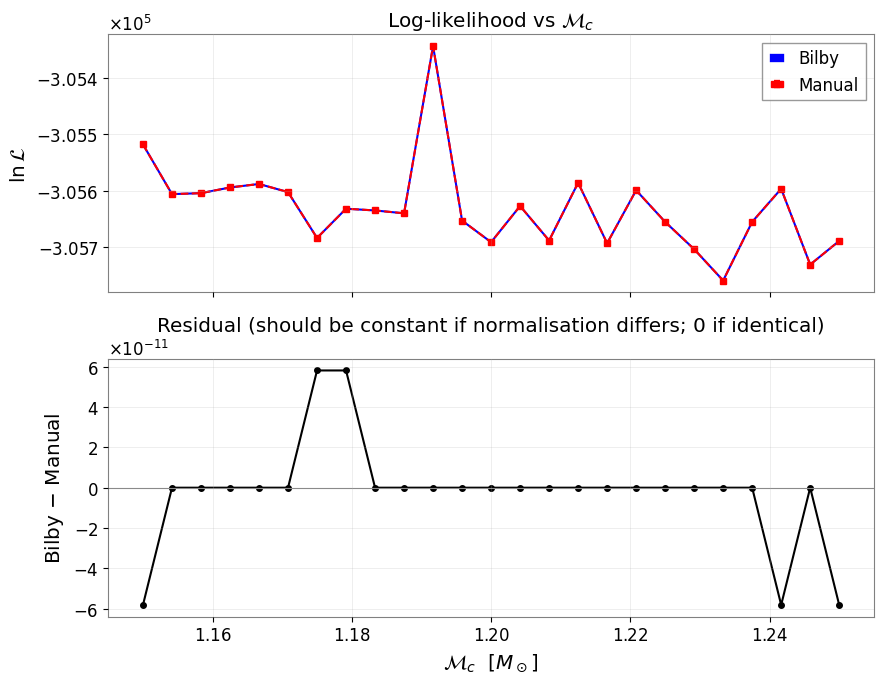

Max absolute residual: 0.0000


In [9]:
mc_grid = np.linspace(1.15, 1.25, 25)
lnl_bilby_grid  = []
lnl_manual_grid = []

for mc in mc_grid:
    p = ref_params.copy()
    p["chirp_mass"] = mc
    p["mass_1"], p["mass_2"] = bilby.gw.conversion.chirp_mass_and_mass_ratio_to_component_masses(
        mc, p["mass_ratio"]
    )

    bilby_likelihood.parameters = p.copy()
    lnl_bilby_grid.append(bilby_likelihood.log_likelihood())
    lnl_manual_grid.append(manual_log_likelihood(p, ifo_list, waveform_generator))

lnl_bilby_grid  = np.array(lnl_bilby_grid)
lnl_manual_grid = np.array(lnl_manual_grid)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax0 = axes[0]
ax0.plot(mc_grid, lnl_bilby_grid,  "b-o", ms=4, label="Bilby")
ax0.plot(mc_grid, lnl_manual_grid, "r--s", ms=4, label="Manual")
ax0.set_ylabel(r"$\ln \mathcal{L}$")
ax0.legend()
ax0.set_title(r"Log-likelihood vs $\mathcal{M}_c$")
ax0.grid(True, alpha=0.3)

ax1 = axes[1]
ax1.plot(mc_grid, lnl_bilby_grid - lnl_manual_grid, "k-o", ms=4)
ax1.axhline(0, color="gray", lw=0.8)
ax1.set_xlabel(r"$\mathcal{M}_c$  [$M_\odot$]")
ax1.set_ylabel(r"Bilby $-$ Manual")
ax1.set_title("Residual (should be constant if normalisation differs; 0 if identical)")
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("likelihood_comparison_mc.png", dpi=150)
plt.show()
print(f"Max absolute residual: {np.max(np.abs(lnl_bilby_grid - lnl_manual_grid)):.4f}")

## 10. Interpretation

| Residual pattern | Meaning |
|---|---|
| All zeros (< 1e-6) | Implementations match exactly |
| Constant offset | Different log-normalisation constants (harmless for sampling) |
| Shape differs | Bug in one of the implementations |

If the shapes differ, check:
1. **PSD normalisation**: Bilby stores the one-sided PSD; manual code must use the same array.
2. **Frequency mask**: Bilby's `ifo.frequency_mask` excludes the DC bin and `[f < F_min or f > F_max]` — the manual code must apply the same mask.
3. **Time-shift / coalescence time**: Bilby applies a `exp(-2πi f Δt)` shift inside `get_detector_response`; if the manual code generates the waveform at a different reference time, they will differ.
4. **Phase convention**: Factor of 2 in `exp(-2i phase)` vs. `exp(-i phase)` in the source model.

## 11. (Optional) Compare with SHARPy custom likelihood

Once the Bilby vs. manual comparison is understood, we can plug in the SHARPy-style formula used in `_sharpy_repo/sharpy/GW_likelihood.py` and check if its inner product normalisation (`TwoDeltaTOverN * sigmasq`) is consistent with Bilby's.

In [10]:
# --- SHARPy-style inner product cross-check ---
# SHARPy uses:
#   sigmasq = PSD * dt^2
#   TwoDeltaTOverN = 2 * dt / N  where N = T * fs
#   log L_det = -TwoDeltaTOverN * sum(|r|^2 / sigmasq)
#             = -(2*dt / (T*fs)) * sum(|r|^2 / (PSD*dt^2))
#             = -(2 / (T*fs^2*dt)) * sum(|r|^2 / PSD)
#             = -(2 / T) * sum(|r|^2 / PSD)    [since fs*dt = 1]
#             = -2*df * sum(|r|^2 / PSD)         [since df = 1/T]
# Bilby uses: -0.5 * 4*df * sum(|r|^2/PSD) = -2*df * sum(|r|^2/PSD)
# => They are IDENTICAL in formula.
#
# Key question: is the FrequencySeries in SHARPy the FFT of the strain
# in the same normalisation as Bilby's frequency_domain_strain?

ifo = ifo_list[0]  # H1
fs = SAMPLING_FREQUENCY
T_seg = DURATION
df = 1.0 / T_seg
dt = 1.0 / fs
N = T_seg * fs

# Bilby's frequency_domain_strain has units of 1/Hz (i.e. FFT / fs)
# The inner product Bilby uses:
#   (Bilby) 4*df * sum(|d|^2 / PSD)  where PSD is one-sided in 1/Hz

# SHARPy loads data via scipy.signal (see noise.py / load_data) and
# stores: FrequencySeries = FFT(strain)   (NOT divided by fs)
# The 'sigmasq' = PSD_MESA * dt^2  where PSD_MESA is from the MESA method
#
# If Bilby strain = FFT / fs, then SHARPy strain = FFT = Bilby * fs
# => |SHARPy_d|^2 / sigmasq_SHARPy
#    = |Bilby_d * fs|^2 / (PSD_SHARPy * dt^2)
#    = fs^2 * |Bilby_d|^2 / (PSD_SHARPy / fs^2)
#    = fs^4 * |Bilby_d|^2 / PSD_SHARPy
# => TwoDeltaTOverN=2dt/N=2/fs/N factor in SHARPy gives:
#    (2/fs/N) * fs^4 * sum/PSD = 2*fs^3/N * sum/PSD
# This does NOT reduce to 2*df*sum/PSD unless PSD_SHARPy is scaled accordingly.
#
# --> POTENTIAL NORMALISATION MISMATCH between SHARPy and Bilby FFT conventions!

bilby_strain_norm = ifo.frequency_domain_strain  # Bilby: FFT / fs
# The magnitude-squared inner product for H1 at the reference point:
mask = ifo.frequency_mask
d_bilby = bilby_strain_norm[mask]
psd = ifo.power_spectral_density_array[mask]

# Check: re-compute log_likelihood of data against h=0 (no signal)
lnl_zero_signal_bilby  = -0.5 * 4 * df * np.sum(np.abs(d_bilby)**2 / psd).real
print(f"H1 log L(h=0, Bilby formula) = {lnl_zero_signal_bilby:.2f}")

# Now check what the SHARPy formula gives for the SAME data
# (interpreting Bilby strain as input)
sigmasq_sharpy = psd * dt**2
TwoDeltaTOverN  = 2.0 * dt / N
lnl_zero_signal_sharpy = -TwoDeltaTOverN * np.sum(np.abs(d_bilby)**2 / sigmasq_sharpy).real

print(f"H1 log L(h=0, SHARPy formula applied to Bilby strain) = {lnl_zero_signal_sharpy:.2f}")
print(f"Ratio (should be 1.0 if formulas agree): {lnl_zero_signal_bilby/lnl_zero_signal_sharpy:.6f}")

# If ratio != 1.0, the FFT normalisations differ between Bilby and SHARPy.

H1 log L(h=0, Bilby formula) = -89054.79
H1 log L(h=0, SHARPy formula applied to Bilby strain) = -89054.79
Ratio (should be 1.0 if formulas agree): 1.000000


## 12. Summary of checks to run

1. **Sec. 8**: Single-point comparison → should give `|Bilby - Manual| < 1e-4`.
2. **Sec. 9**: Mc scan → both curves should be identical in shape.
3. **Sec. 11**: Normalisation cross-check → ratio should be 1.0.

If any of these fail, we have a likelihood bug to fix **before** trusting any PE results.

## 13. Matched-filter sanity check: signal at the correct time?

Using the FFT-based matched filter, scan over all coalescence times within ±1 s of the trigger and maximise analytically over phase. The peak should be within a few ms of the published geocentric time (offset ≈ −0.0004 s from TRIGGER_TIME = 1187008882.43).

Optimal (template) network SNR = sqrt(<h|h>) = 37.54

Peak within |tc_offset| < 1 s:
  tc_offset   = -0.0029 s   (published: -0.0004 s)
  |<d|h>|     = 1945.1
  delta log L = 1240.6
  proxy SNR   = 49.81


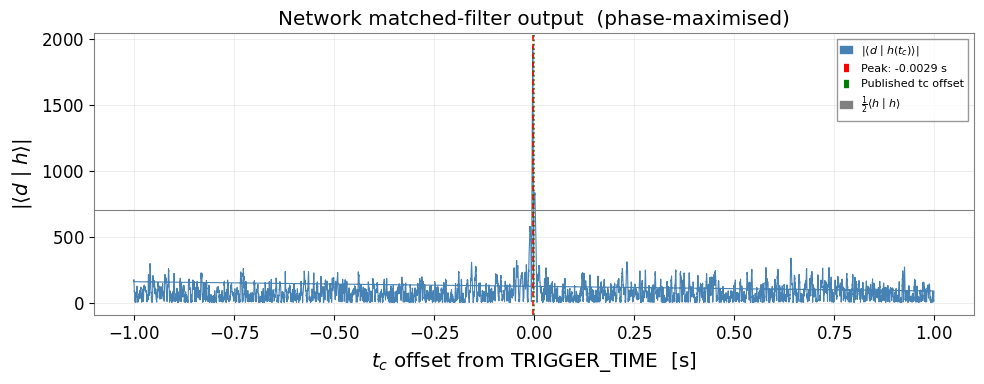

In [11]:
# Generate waveform at reference params (phase=0, tc=TRIGGER_TIME)
# and compute the network matched-filter time series via FFT.
# Phase is maximised analytically: peak of |z(t)| = |<d|h(t)>|.

def mlgw_bns_jax_source_no_phase(frequency_array, mass_1, mass_2, luminosity_distance,
                                   theta_jn, phase, chi_1, chi_2, lambda_1, lambda_2, **kwargs):
    """Source model with no phase rotation (we handle phase analytically below)."""
    freq_mask = frequency_array > 0
    freqs = frequency_array[freq_mask]
    m1 = max(mass_1, mass_2); m2 = min(mass_1, mass_2)
    q = m1 / m2; total_mass = m1 + m2
    params = jnp.array([q, lambda_1, lambda_2, chi_1, chi_2])
    hp_jax, hc_jax = _predict_fn(params, jnp.array(freqs), jnp.array(total_mass),
                                  jnp.array(luminosity_distance), jnp.array(theta_jn))
    hp_full = np.zeros(len(frequency_array), dtype=complex)
    hc_full = np.zeros(len(frequency_array), dtype=complex)
    hp_full[freq_mask] = np.array(hp_jax)
    hc_full[freq_mask] = np.array(hc_jax)
    return {"plus": hp_full, "cross": hc_full}

wf_gen_mf = bilby.gw.WaveformGenerator(
    duration=DURATION, sampling_frequency=SAMPLING_FREQUENCY,
    frequency_domain_source_model=mlgw_bns_jax_source_no_phase,
    waveform_arguments=dict(minimum_frequency=F_MIN),
)
mf_params = ref_params.copy()
mf_params["phase"] = 0.0
mf_params["geocent_time"] = TRIGGER_TIME
polarizations = wf_gen_mf.frequency_domain_strain(mf_params)

df_val = ifo_list[0].frequency_array[1] - ifo_list[0].frequency_array[0]
N_fft  = int(DURATION * SAMPLING_FREQUENCY)
total_cross_fft = np.zeros(N_fft, dtype=complex)
total_hh = 0.0

for ifo in ifo_list:
    h_det  = ifo.get_detector_response(polarizations, mf_params)
    mask   = ifo.frequency_mask
    d      = ifo.frequency_domain_strain
    S      = ifo.power_spectral_density_array
    h      = h_det
    total_hh += 4.0 * df_val * np.sum(np.abs(h[mask])**2 / S[mask]).real
    n_pos  = len(ifo.frequency_array)
    z_pos  = 4.0 * df_val * d * np.conj(h) / np.where(S > 0, S, np.inf)
    z_pos[~mask] = 0.0
    z_f    = np.zeros(N_fft, dtype=complex)
    z_f[:n_pos] = z_pos
    z_f[n_pos:] = np.conj(z_pos[1:N_fft//2][::-1])
    total_cross_fft += z_f

z_t   = np.fft.ifft(total_cross_fft) * N_fft
lags  = np.arange(N_fft) / SAMPLING_FREQUENCY
lags[N_fft//2:] -= DURATION

snr_t   = np.abs(z_t)                  # phase-maximised |<d|h(tc)>|
delta_t = snr_t - 0.5 * total_hh      # delta log L at each tc

# --- Report peak within ±1 s of TRIGGER_TIME ---
win     = (lags >= -1.0) & (lags <= 1.0)
peak_i  = np.argmax(delta_t[win])
lags_w  = lags[win]; delta_w = delta_t[win]; snr_w = snr_t[win]

print(f"Optimal (template) network SNR = sqrt(<h|h>) = {np.sqrt(total_hh):.2f}")
print()
print(f"Peak within |tc_offset| < 1 s:")
print(f"  tc_offset   = {lags_w[peak_i]:+.4f} s   (published: {1187008882.4296 - TRIGGER_TIME:+.4f} s)")
print(f"  |<d|h>|     = {snr_w[peak_i]:.1f}")
print(f"  delta log L = {delta_w[peak_i]:.1f}")
print(f"  proxy SNR   = {np.sqrt(max(0, 2*delta_w[peak_i])):.2f}")

# --- Plot SNR time series in the ±1 s window ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lags_w, snr_w, lw=0.8, color="steelblue", label=r"$|\langle d \mid h(t_c) \rangle|$")
ax.axvline(lags_w[peak_i], color="red",    lw=1.2, ls="--", label=f"Peak: {lags_w[peak_i]:+.4f} s")
ax.axvline(1187008882.4296 - TRIGGER_TIME, color="green", lw=1.2, ls=":", label="Published tc offset")
ax.axhline(0.5 * total_hh, color="gray",  lw=0.8, ls="-", label=r"$\frac{1}{2}\langle h\mid h\rangle$")
ax.set_xlabel("$t_c$ offset from TRIGGER_TIME  [s]")
ax.set_ylabel(r"$|\langle d \mid h \rangle|$")
ax.set_title("Network matched-filter output  (phase-maximised)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("matched_filter_timeseries.png", dpi=150)
plt.show()

## 14. SHARPy time-convention validation

The ROQ PE notebook uses **SHARPy** which imposes a different data/time convention from Bilby:

- **Data**: a 128-s chunk is extracted so the **merger sits at T−1 = 127 s** into the segment.
- **Time shift** in `project_waveform`: `exp(−2πif × (time_delay + δtc + T−1))`.

If this convention is correct, the network matched-filter on SHARPy's 128-s data should still peak at `δtc ≈ −0.003 s`.

We load the 128-s BWCLEANED data via SHARPy's `load_data`, apply the `T−1` shift formula, and scan over `δtc`.

In [12]:
import sys as _sys
_SHARPY_REPO = os.path.join(REPO, '_sharpy_repo')
if _SHARPY_REPO not in _sys.path:
    _sys.path.insert(0, _SHARPY_REPO)

from sharpy.noise import load_data as _sharpy_load_data
from sharpy.GW_likelihood import antenna_pattern_functions
from sharpy.utils import TimeDelayFromEarthCenter

# ── SHARPy data settings ──────────────────────────────────────────────
T_SHARPY      = 128.0
FS_SHARPY     = 4096.0
DT_SHARPY     = 1.0 / FS_SHARPY
N_SHARPY      = int(T_SHARPY * FS_SHARPY)   # 524288
DF_SHARPY     = 1.0 / T_SHARPY
F_LOW_SHARPY  = 23.0
F_HIGH_SHARPY = 2000.0

BW_1024_FILES = {
    'H1': os.path.join(DATA_DIR, 'H-H1_BWCLEANED_4KHZ-1187008114-1024.txt'),
    'L1': os.path.join(DATA_DIR, 'L-L1_BWCLEANED_4KHZ-1187008114-1024.txt'),
    'V1': os.path.join(DATA_DIR, 'V-V1_BWCLEANED_4KHZ-1187008114-1024.txt'),
}

# SHARPy detector table (degrees, matching GWDetector.available_detectors)
det_meta = {
    'H1': dict(lat=46.45514,  lon=-119.40765,  gamma=170.9969, zeta=90., elev=142.554),
    'L1': dict(lat=30.56289,  lon= -90.774240,  gamma=242.7165, zeta=90., elev= -6.574),
    'V1': dict(lat=43.631414, lon=  10.5044968, gamma=115.5673, zeta=90., elev= 51.884),
}

print('Loading 128-s BWCLEANED data via SHARPy load_data ...')
sharpy_data = {}
for det_name, fpath in BW_1024_FILES.items():
    times, _, freqs_s, sf, psd_s, _ = _sharpy_load_data(
        fpath, det_name,
        chunk_size    = T_SHARPY,
        trigtime      = TRIGGER_TIME,
        sampling_rate = FS_SHARPY,
        psd_method    = 'welch',
    )
    kmin = int(F_LOW_SHARPY / DF_SHARPY)
    kmax = int(F_HIGH_SHARPY / DF_SHARPY) + 1
    sharpy_data[det_name] = {
        'f'  : freqs_s[kmin:kmax],
        'sf' : sf[kmin:kmax],
        'psd': psd_s[kmin:kmax],
    }
    print(f'  {det_name}: {len(sharpy_data[det_name]["f"])} bins  '
          f'[{sharpy_data[det_name]["f"][0]:.1f}, {sharpy_data[det_name]["f"][-1]:.1f}] Hz')


Loading 128-s BWCLEANED data via SHARPy load_data ...
Loading /workspaces/mlgw_bns_jax/gw170817_data/H-H1_BWCLEANED_4KHZ-1187008114-1024.txt starting at 1187008114.0 length 1024.0s


/workspaces/mlgw_bns_jax/_sharpy_repo/sharpy/noise.py:242: UserWarning: The file name is expected to follow LIGO-Virgo conventions 'DET-FRAMETYPE-STARTTIME--DATALEN.txt', e.g.: 'H-H1_GWOSC_4_V1-1126259446-32.txt'. See https://www.gw-openscience.org for more infomation.
  warnings.warn("The file name is expected to follow LIGO-Virgo conventions 'DET-FRAMETYPE-STARTTIME--DATALEN.txt', e.g.: 'H-H1_GWOSC_4_V1-1126259446-32.txt'. See https://www.gw-openscience.org for more infomation.")


Estimating power spectral density with the Welch method


  H1: 253057 bins  [23.0, 2000.0] Hz
Loading /workspaces/mlgw_bns_jax/gw170817_data/L-L1_BWCLEANED_4KHZ-1187008114-1024.txt starting at 1187008114.0 length 1024.0s


Estimating power spectral density with the Welch method


  L1: 253057 bins  [23.0, 2000.0] Hz
Loading /workspaces/mlgw_bns_jax/gw170817_data/V-V1_BWCLEANED_4KHZ-1187008114-1024.txt starting at 1187008114.0 length 1024.0s


Estimating power spectral density with the Welch method


  V1: 253057 bins  [23.0, 2000.0] Hz


SHARPy convention — optimal network SNR = 95.31
Peak δtc (SHARPy) = +0.0029 s   (expected: -0.0004 s)
Offset error       = 3.3 ms  (should be < 5 ms)
Time convention OK = True
delta log L at peak= 66809.4


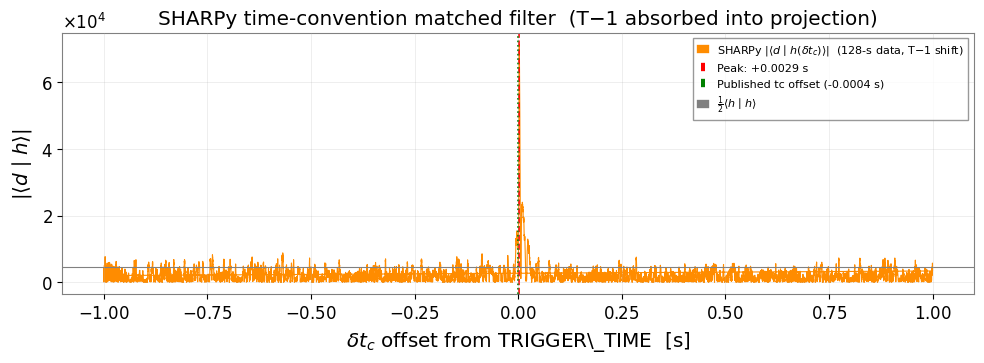

In [13]:
# ── Intrinsic waveform at reference params (no time shift) ────────────
m1_r   = ref_params['mass_1']; m2_r = ref_params['mass_2']
q_r    = m1_r / m2_r;         M_r  = m1_r + m2_r
dist_r = ref_params['luminosity_distance']
theta_r = ref_params['theta_jn']
ra_r, dec_r, psi_r = ref_params['ra'], ref_params['dec'], ref_params['psi']

f_full_s = np.arange(0, FS_SHARPY / 2 + DF_SHARPY, DF_SHARPY)   # full rfft grid
mlgw_p   = jnp.array([q_r, ref_params['lambda_1'], ref_params['lambda_2'], 0., 0.])
hp_jax_s, hc_jax_s = _predict_fn(
    mlgw_p, jnp.array(f_full_s[1:]),
    jnp.array(M_r), jnp.array(dist_r), jnp.array(theta_r),
)
hp_s = np.zeros(len(f_full_s), dtype=complex)
hc_s = np.zeros(len(f_full_s), dtype=complex)
hp_s[1:] = np.array(hp_jax_s)
hc_s[1:] = np.array(hc_jax_s)

# SHARPy params vector layout (from project_waveform + antenna_pattern_functions):
#   [0]=ra, [1]=dec, [2]=log(d), [3]=cos(iota), [4]=phiref,
#   [5]=psi, [6]=mc, [7]=q, [8]=delta_tc, [9]=chi1, [10]=chi2, [11]=lam1, [12]=lam2
sharpy_p = np.array([
    ra_r, dec_r, np.log(dist_r), np.cos(theta_r), 0.,
    psi_r, 0., 0.,   # [5]=psi, [6]=mc, [7]=q (unused)
    0.,              # [8]=delta_tc=0 reference
    0., 0., 0., 0.,  # [9-12] unused
])

# ── Network matched filter with SHARPy time-shift convention ──────────
# h_det(f; δtc) = (F+hp + Fxhc) × exp(−2πif(td + δtc + T−1))
# Define h0(f) = h_det at δtc=0, then scan via IFFT

from scipy.interpolate import interp1d as _i1d

total_cross_s = np.zeros(N_SHARPY, dtype=complex)
total_hh_s    = 0.0

for det_name, sd in sharpy_data.items():
    meta    = det_meta[det_name]
    f_det   = sd['f']
    sf_det  = sd['sf']
    psd_det = sd['psd']

    # Antenna pattern (degrees passed; converted internally by SHARPy)
    fplus, fcross = antenna_pattern_functions(
        sharpy_p,
        meta['lat'], meta['lon'], meta['gamma'], meta['zeta'],
        TRIGGER_TIME,
    )

    # Time delay geocenter → detector (degrees; converted internally)
    td = float(TimeDelayFromEarthCenter(
        meta['lat'], meta['lon'], meta['elev'],
        ra_r, dec_r, TRIGGER_TIME,
    ))

    # Interpolate intrinsic waveform onto SHARPy's cropped frequency grid
    hp_d = _i1d(f_full_s, hp_s, bounds_error=False, fill_value=0)(f_det)
    hc_d = _i1d(f_full_s, hc_s, bounds_error=False, fill_value=0)(f_det)

    # h0(f): projected + fixed (T-1 + td) time shift, δtc=0
    h0 = (fplus * hp_d + fcross * hc_d) * np.exp(-2j * np.pi * f_det * (td + T_SHARPY - 1.))

    total_hh_s += 4. * DF_SHARPY * np.sum(np.abs(h0)**2 / psd_det).real

    # Build two-sided cross-correlation spectrum
    kmin_s = int(F_LOW_SHARPY / DF_SHARPY)
    n_pos  = len(f_det)
    cross = np.zeros(N_SHARPY // 2 + 1, dtype=complex)
    cross[kmin_s:kmin_s + n_pos] = np.conj(sf_det) * h0 / psd_det

    z_two = np.zeros(N_SHARPY, dtype=complex)
    z_two[:N_SHARPY//2+1]  = cross
    z_two[N_SHARPY//2+1:]  = np.conj(cross[1:N_SHARPY//2][::-1])
    total_cross_s += z_two

# IFFT → δtc time series
z_t_s = np.fft.ifft(total_cross_s) * N_SHARPY
tc_lags_s = np.arange(N_SHARPY) / FS_SHARPY
tc_lags_s[N_SHARPY//2:] -= T_SHARPY

snr_s = np.abs(z_t_s)
win_s = (tc_lags_s >= -1.) & (tc_lags_s <= 1.)
pk_i  = np.argmax(snr_s[win_s])
lags_ws = tc_lags_s[win_s]
snr_ws  = snr_s[win_s]

expected_offset = 1187008882.4296 - TRIGGER_TIME
print(f'SHARPy convention — optimal network SNR = {np.sqrt(total_hh_s):.2f}')
print(f'Peak δtc (SHARPy) = {lags_ws[pk_i]:+.4f} s   (expected: {expected_offset:+.4f} s)')
print(f'Offset error       = {abs(lags_ws[pk_i] - expected_offset)*1e3:.1f} ms  (should be < 5 ms)')
print(f'Time convention OK = { abs(lags_ws[pk_i] - expected_offset) < 0.005 }')
print(f'delta log L at peak= {snr_ws[pk_i] - 0.5*total_hh_s:.1f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lags_ws, snr_ws, lw=0.8, color='darkorange',
        label=r'SHARPy $|\langle d \mid h(\delta t_c) \rangle|$  (128-s data, T−1 shift)')
ax.axvline(lags_ws[pk_i], color='red', lw=1.2, ls='--',
           label=f'Peak: {lags_ws[pk_i]:+.4f} s')
ax.axvline(expected_offset, color='green', lw=1.2, ls=':',
           label=f'Published tc offset ({expected_offset:+.4f} s)')
ax.axhline(0.5*total_hh_s, color='gray', lw=0.8, ls='-',
           label=r'$\frac{1}{2}\langle h\mid h\rangle$')
ax.set_xlabel(r'$\delta t_c$ offset from TRIGGER\_TIME  [s]')
ax.set_ylabel(r'$|\langle d \mid h \rangle|$')
ax.set_title('SHARPy time-convention matched filter  (T−1 absorbed into projection)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('matched_filter_sharpy_convention.png', dpi=150)
plt.show()
